In [8]:
import numpy as np
import pandas as pd
from scipy.signal import butter,filtfilt,welch
import matplotlib.pyplot as plt


In [9]:
nasal = pd.read_csv("Data/AP01/nasal_airflow.csv")
nasal['Timestamp']=pd.to_datetime(nasal['Timestamp'],format="%d.%m.%Y %H:%M:%S,%f")

In [10]:
nasal.set_index('Timestamp',inplace=True)

In [11]:
nasal['nasal_airflow'].values

array([120, 120,  84, ...,  -5,  -5,  -5], shape=(875184,))

In [12]:
nasal.to_numpy()

array([[120],
       [120],
       [ 84],
       ...,
       [ -5],
       [ -5],
       [ -5]], shape=(875184, 1))

In [13]:
f,Pxx =welch(nasal['nasal_airflow'].values,fs=32)

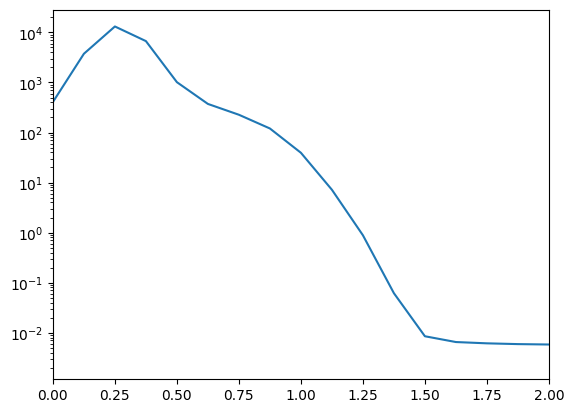

In [14]:
plt.semilogy(f,Pxx)
plt.xlim(0, 2)
plt.show()

In [15]:
fs = 32
nyq = 0.5*fs
lowcut =0.17
highcut =0.4

low = lowcut/nyq
high = highcut/nyq

b,a = butter(N=4,Wn=[low,high],btype ='bandpass')
print(b,a)

[ 2.45232568e-07  0.00000000e+00 -9.80930270e-07  0.00000000e+00
  1.47139541e-06  0.00000000e+00 -9.80930270e-07  0.00000000e+00
  2.45232568e-07] [  1.          -7.87166379  27.11984054 -53.41284101  65.77491456
 -51.85982286  25.56572308  -7.20482741   0.8886769 ]


In [16]:
filtered_signal = filtfilt(b,a,nasal['nasal_airflow'].values)

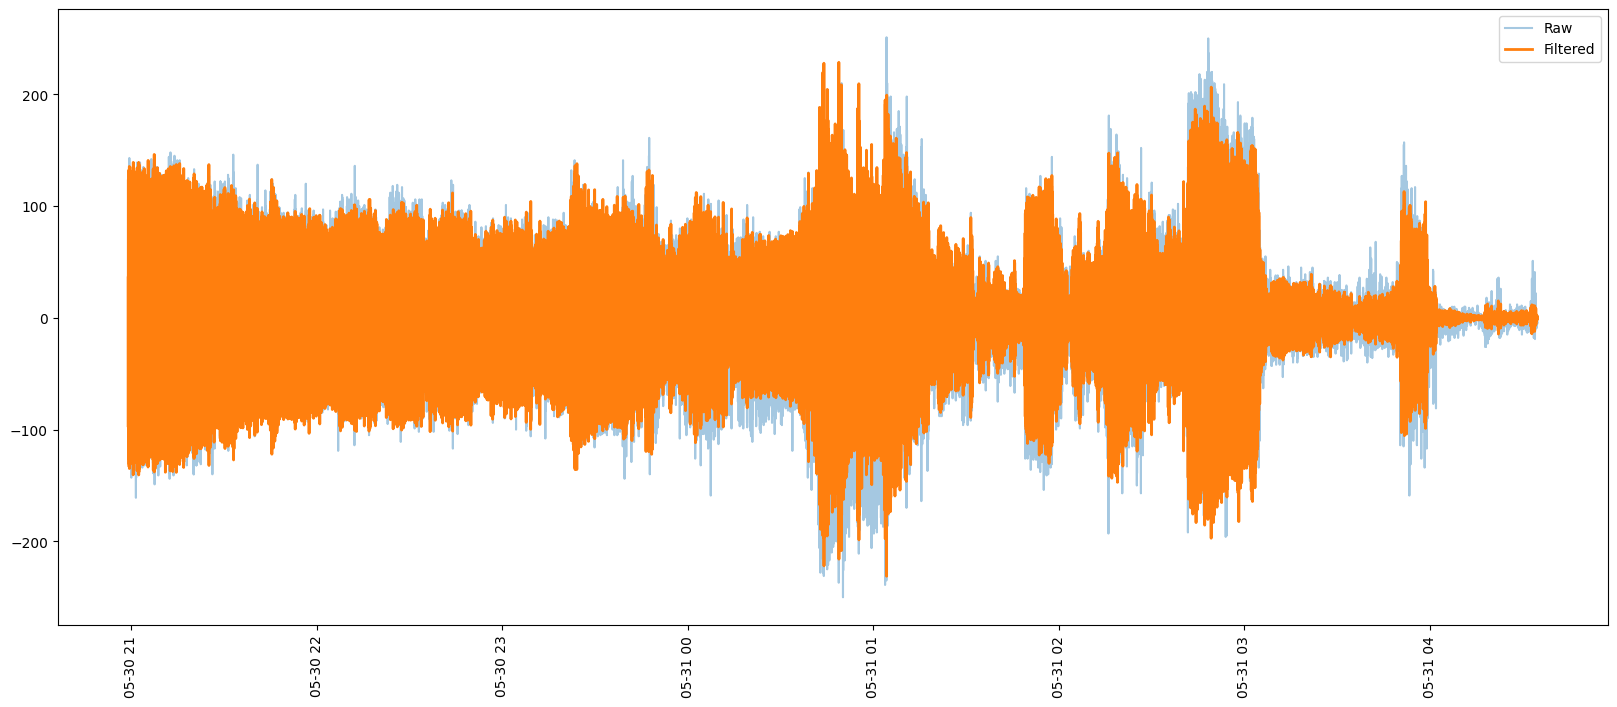

In [17]:
fig,ax= plt.subplots(figsize=(20,8))
plt.plot(nasal.index, nasal['nasal_airflow'].values, alpha=0.4, label='Raw')
plt.plot(nasal.index, filtered_signal, label='Filtered', linewidth=2)
plt.xticks(rotation=90, fontsize=10)
plt.legend()
plt.show()

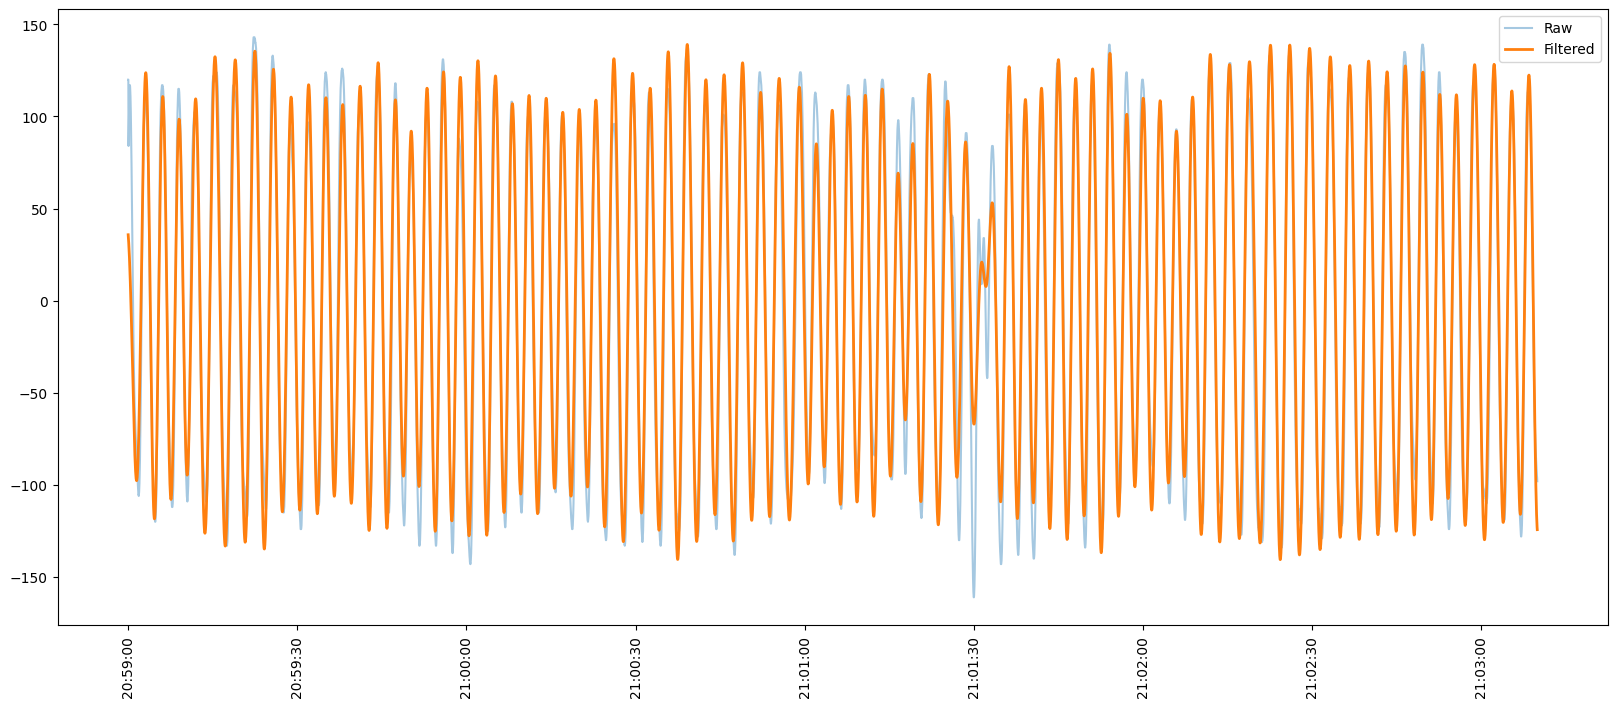

In [18]:
fig,ax= plt.subplots(figsize=(20,8))
plt.plot(nasal.index[:8000], nasal['nasal_airflow'].values[:8000], alpha=0.4, label='Raw')
plt.plot(nasal.index[:8000], filtered_signal[:8000], label='Filtered', linewidth=2)
plt.xticks(rotation=90, fontsize=10)
plt.legend()
plt.show()

## Sampling

In [19]:
fs=32
ts = 30
window_size = fs*ts
step =int(0.5*window_size)

windows =[]
window_time =[]
signal= nasal['nasal_airflow'].values
timestamp =nasal.index.values
for i in range(0,len(signal)- window_size,step):
    start = timestamp[i]
    end = timestamp[i+window_size-1]
    windows.append(signal[i:i+window_size])
    window_time.append((start,end))

windows =np.array(windows)
window_time = np.array(window_time)

In [20]:
windows

array([[120, 120,  84, ..., -62, -67, -72],
       [119, 120, 121, ...,  63,  55,  47],
       [-77, -81, -84, ..., -88, -93, -97],
       ...,
       [ -5,  -5,  -5, ...,  12,  12,  12],
       [ 38,  39,  40, ...,  -8,  -8,  -8],
       [ 12,  12,  12, ...,  -2,  -2,  -2]], shape=(1822, 960))

In [21]:
flow_events = pd.read_csv('Data/AP01/flow_events.csv')

In [22]:
flow_events['start'] =pd.to_datetime(flow_events['Timerange'].str.split(" ").str[0] + " " + flow_events['Timerange'].str.split(" ").str[1].str.split("-").str[0],format="%d.%m.%Y %H:%M:%S,%f")
flow_events['end'] =pd.to_datetime(flow_events['Timerange'].str.split(" ").str[0] + " " + flow_events['Timerange'].str.split(" ").str[1].str.split("-").str[1],format="%d.%m.%Y %H:%M:%S,%f")
flow_events.drop(columns={'Timerange'},inplace=True)
flow_events.head()

,Impulse,Events,Stage,start,end
0,16,Hypopnea,N1,2024-05-30 23:48:45.119,2024-05-30 23:49:01.408
1,17,Hypopnea,N1,2024-05-30 23:50:16.578,2024-05-30 23:50:33.546
2,14,Hypopnea,N1,2024-05-30 23:52:13.626,2024-05-30 23:52:27.268
3,12,Hypopnea,N1,2024-05-30 23:52:51.246,2024-05-30 23:53:02.871
4,13,Hypopnea,N1,2024-05-30 23:53:36.906,2024-05-30 23:53:49.734


In [23]:
event_labels =[]
events_np = flow_events.to_numpy()
for i in range(len(window_time)):
    win_start,win_end =  window_time[i]
    win_duration = win_end- win_start

    max_overlap =0
    event_label ="Normal"

    for j in range(len(events_np)):
        curr_event = flow_events.iloc[j]
        overlap = min(curr_event['end'],win_end)-max(curr_event['start'],win_start)
        overlap_ratio = overlap/win_duration
            
        if overlap_ratio > max_overlap:
                max_overlap=overlap_ratio
                event_label = curr_event["Events"]
    if max_overlap>0.5:
        event_labels.append(event_label)
    else:
        event_labels.append("Normal")
print(events_np)



[[16 'Hypopnea' ' N1' Timestamp('2024-05-30 23:48:45.119000')
  Timestamp('2024-05-30 23:49:01.408000')]
 [17 'Hypopnea' ' N1' Timestamp('2024-05-30 23:50:16.578000')
  Timestamp('2024-05-30 23:50:33.546000')]
 [14 'Hypopnea' ' N1' Timestamp('2024-05-30 23:52:13.626000')
  Timestamp('2024-05-30 23:52:27.268000')]
 [12 'Hypopnea' ' N1' Timestamp('2024-05-30 23:52:51.246000')
  Timestamp('2024-05-30 23:53:02.871000')]
 [13 'Hypopnea' ' N1' Timestamp('2024-05-30 23:53:36.906000')
  Timestamp('2024-05-30 23:53:49.734000')]
 [14 'Hypopnea' ' N1' Timestamp('2024-05-30 23:54:41.454000')
  Timestamp('2024-05-30 23:54:55.605000')]
 [27 'Hypopnea' ' N1' Timestamp('2024-05-30 23:56:54.246000')
  Timestamp('2024-05-30 23:57:21.121000')]
 [15 'Hypopnea' ' N1' Timestamp('2024-05-30 23:57:31.374000')
  Timestamp('2024-05-30 23:57:45.933000')]
 [24 'Hypopnea' ' N1' Timestamp('2024-05-30 23:57:55.246000')
  Timestamp('2024-05-30 23:58:18.871000')]
 [15 'Hypopnea' ' N2' Timestamp('2024-05-30 23:58:31.85

In [24]:
pd.Series(event_labels).unique()

array(['Normal', 'Hypopnea', 'Obstructive Apnea'], dtype=object)

## Saving DataSet

In [25]:
import pickle
dataset={
    'signals':windows,
    'time_window':window_time,
    'labels':event_labels
}
with open('sleep_apnea.pkl',"wb") as f:
    pickle.dump(dataset,f)

In [43]:
with open("internship/Dataset/sleep_stage_dataset.pkl", "rb") as f:
    dataset = pickle.load(f)

signals = dataset["signals"]
labels = dataset["labels"]
window_time =dataset['window_time']

In [45]:
len(labels)

8800